## **Train DPF particle proposer (PP) without resampling + GMM Visualisation**

In [1]:
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
from belief_dynamics_learning.world2d import World2D
from belief_dynamics_learning.dpf import *
from belief_dynamics_learning.dpf_utils import *
import random

%load_ext autoreload
%autoreload 2

### **1. Example demonstration of 2D world**

In [2]:
num_particles = 100
dt = 0.1

# object properties 
dim_object = np.array([0.067, 0.14])
qo_gt = np.array([0, 1, 0]) # ground truth object pose
sigma_pos = 0.06 # standard deviation of position noise

# robot properties
qr_0 = np.array([0, 0.7])
r_robot = 0.05


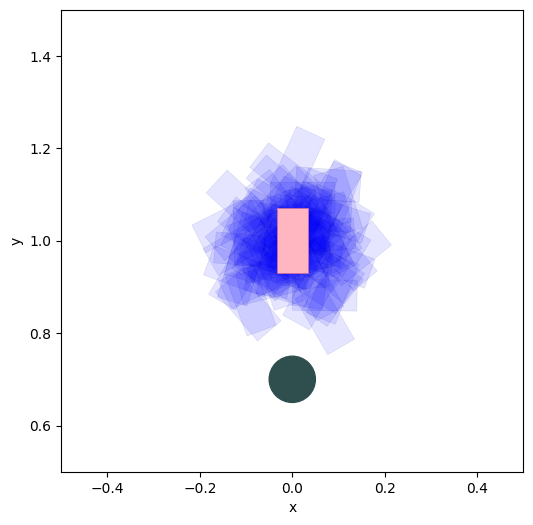

In [3]:
world = World2D(num_particles, qo_gt, dim_object, sigma_pos, 
                qr_0, r_robot, dt)
world.plot_belief()

In [4]:
world.sample_gt_object_pose()
world.sample_robot_pose()
q_r_hist, o_hist, a_hist = world.rollout(100, world.qo_gt.copy())

# only keep bits of sequence around positive contact measurements
contact_idx = np.where(o_hist==1)[0]
if len(contact_idx) == 0:
    print('No contact detected')
else:
    min_idx = np.min(contact_idx)
    max_idx = np.max(contact_idx)
    buffer_lb = np.min([min_idx, 10])
    buffer_ub = np.min([len(o_hist)-max_idx, 10])
    keep_idx = [min_idx-buffer_lb, max_idx+buffer_ub]
    print('Keeping indices:', keep_idx)
    q_r_hist = q_r_hist[keep_idx[0]:keep_idx[1]]
    o_hist = o_hist[keep_idx[0]:keep_idx[1]]
    world.plot_rollout(q_r_hist, o_hist)

No contact detected


### **2.1. Initialize DPF and load dataset**

In [5]:
# initialise hyperparameters for the differentiable particle filter (DPF)
propose_ratio = 0.7
proposer_keep_ratio = 0.15 # what it was set to initially and from the paper code
min_obs_likelihood = 0.004

# initialise hyperparameters for the DPF training
split_ratio = 0.8
seq_len = 2
batch_size = 20
num_epochs_pp = 150
num_epochs_ole = 400
patience = 10
learning_rate = 0.0003
dropout_keep_ratio = 0.7
num_particles = 100
num_particles_test = 300
particle_std = 0.2
contact_only = True
xy_only = False
phi_dataset = True

# create instance of DPF class
dpf = DPF(propose_ratio, proposer_keep_ratio, min_obs_likelihood, num_particles, num_particles_test, world, xy_only, phi_dataset)

Using device: cpu


In [6]:
# find file path to the training data
root = os.getcwd()
save_path = os.path.join(root, '../data/phi_data_min_1_contacts_seq_len_2_test_500_trajectories.pkl')

# ensure the training data file exists before attempting to load it
if os.path.exists(save_path):
    with open(save_path, 'rb') as f:
        raw_data = pickle.load(f)
else:
    print("File not found:", save_path)

Organise data into a dictionary:

Object pose data: (500, 1, 3)
Robot pose data: (500, 1, 2)
q_o_r data: (500, 1, 2)
Phi observation data: (500, 2, 1)
Closest point data: (500, 2, 2)
Object pose (example trajectory): [[0.32384847 0.75476331 0.73801861]]
Robot pose (example trajectory): [0.22638273 0.7378279 ]
q_o_r data (example trajectory): [0.09746575 0.0169354 ]
Phi observation (example trajectory): [0.92029353]
Closest point (example trajectory): [0.04857787 0.03696767]


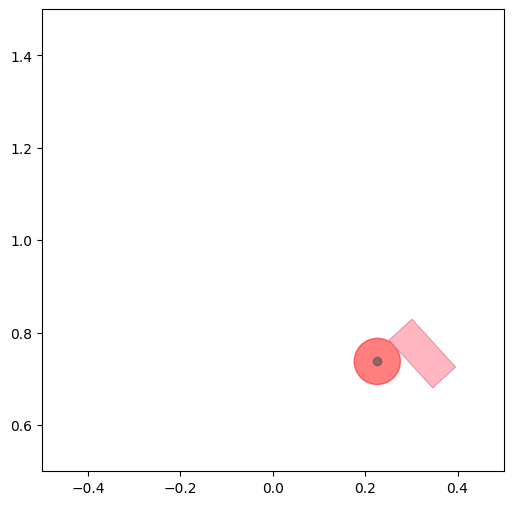

In [7]:
# data generation parameters
num_sequences = 500
num_steps_per_sequence = seq_len

data = organise_data(raw_data, num_sequences, num_steps_per_sequence, contact_only, xy_only)
    
# verify shapes of matrices containing 
print('Object pose data:', data['q_o'].shape)
print('Robot pose data:', data['q_r'].shape)
print('q_o_r data:', data['q_o_r'].shape)
print('Phi observation data:', data['phi'].shape)
print('Closest point data:', data['cp'].shape)

# plot example trajectory from the dataset
traj = np.random.randint(0, num_sequences)
print('Object pose (example trajectory):', data['q_o'][traj, :, :])
print('Robot pose (example trajectory):', data['q_r'][traj, 0, :])
print('q_o_r data (example trajectory):', data['q_o_r'][traj, 0, :])
print('Phi observation (example trajectory):', data['phi'][traj, 0, :])
print('Closest point (example trajectory):', data['cp'][traj, 0, :])
world.qo_gt = data['q_o'][traj, 0, :]
world.plot_rollout(data['q_r'][traj, :, :], 1)
# world.plot_rollout(data['q_r'][traj, :, :], data['o'][traj, :, :])

In [8]:
# noisify data
# data = noisify_data(data)

# compute some statistics aboout the data
means, stds, q_o_r_maxs, q_o_r_mins, q_r_step_sizes, q_r_maxs, q_r_mins = compute_statistics(data, phi_dataset)

/opt/anaconda3/envs/summer-proj/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/envs/summer-proj/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


### **2.2. DPF Training**

Before training, test the:
- particle proposer
- observation likelihood estimator

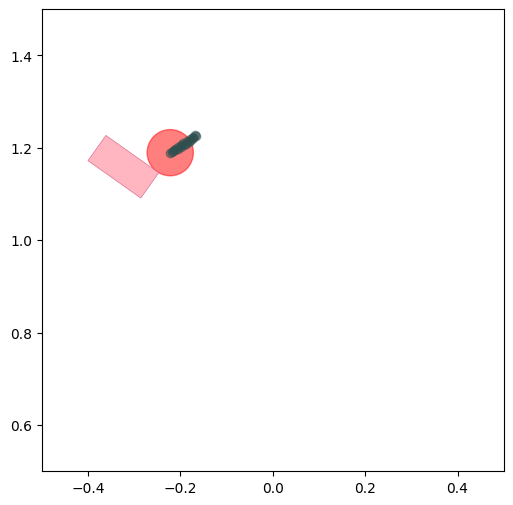

Desired robot position during contact event: tensor([[-0.2231,  1.1878]], dtype=torch.float64)
Achieved robot position during contact event: tensor([[-0.2218,  1.1896]], dtype=torch.float64)
Phi during contact event: tensor([[-2.6512]], dtype=torch.float64)


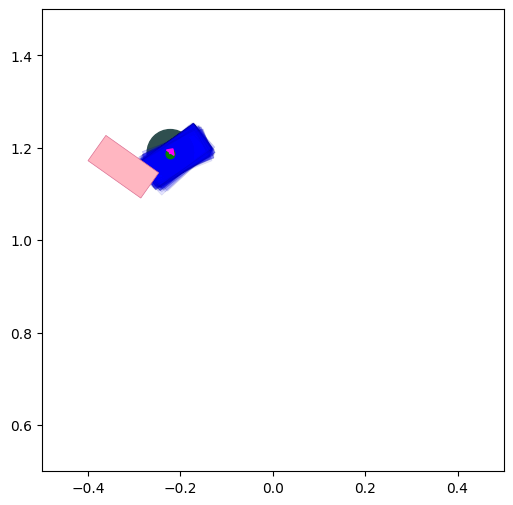

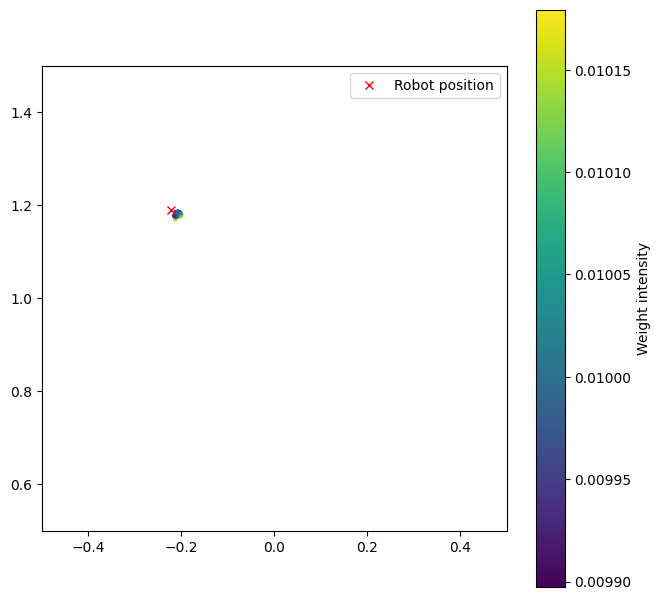

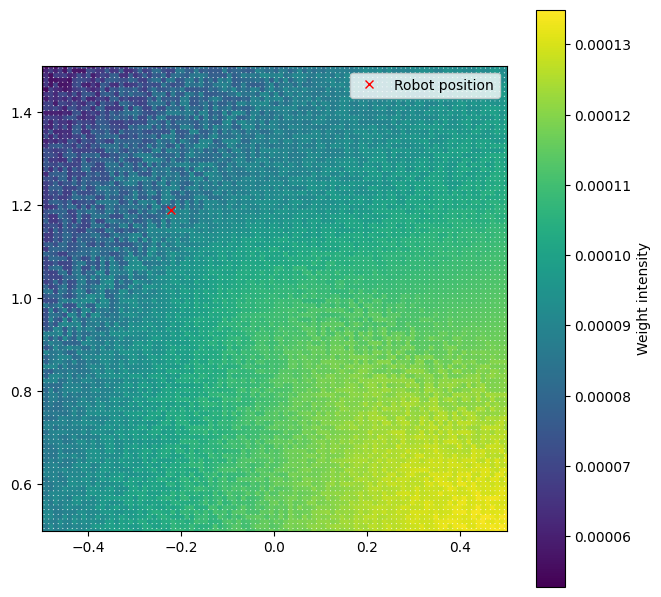

In [9]:
dpf.test(q_o_r_mins, q_o_r_maxs, means, stds, xy_only)

TRAINING PARTICLE PROPOSER
Epoch 1/150
Epoch 11/150
Epoch 21/150
Epoch 31/150
Epoch 41/150
Epoch 51/150
Epoch 61/150
Epoch 71/150
Epoch 81/150
Epoch 91/150
Epoch 101/150
Epoch 111/150
Epoch 121/150
Epoch 131/150
Epoch 141/150


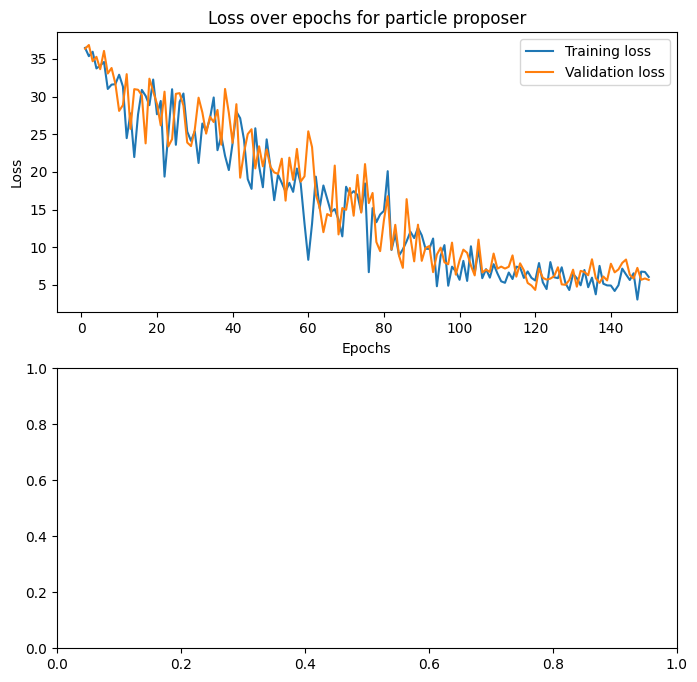

In [10]:
if contact_only == True:
    seq_len = 1

# train the dpf and extract the last batch from training
q_o, particle_list, particle_prob_list = dpf.fit_wo_resampling(data, split_ratio, batch_size, seq_len, num_epochs_pp, patience, learning_rate, num_particles, xy_only, phi_dataset) # form GMM plots

After training:

x
max and min: 1.7444745217707633 1.2999532139680368e-144
y
max and min: 4.4523730674228966e-92 0.0
theta
max and min: 0.3389377931577922 0.03972068807306868


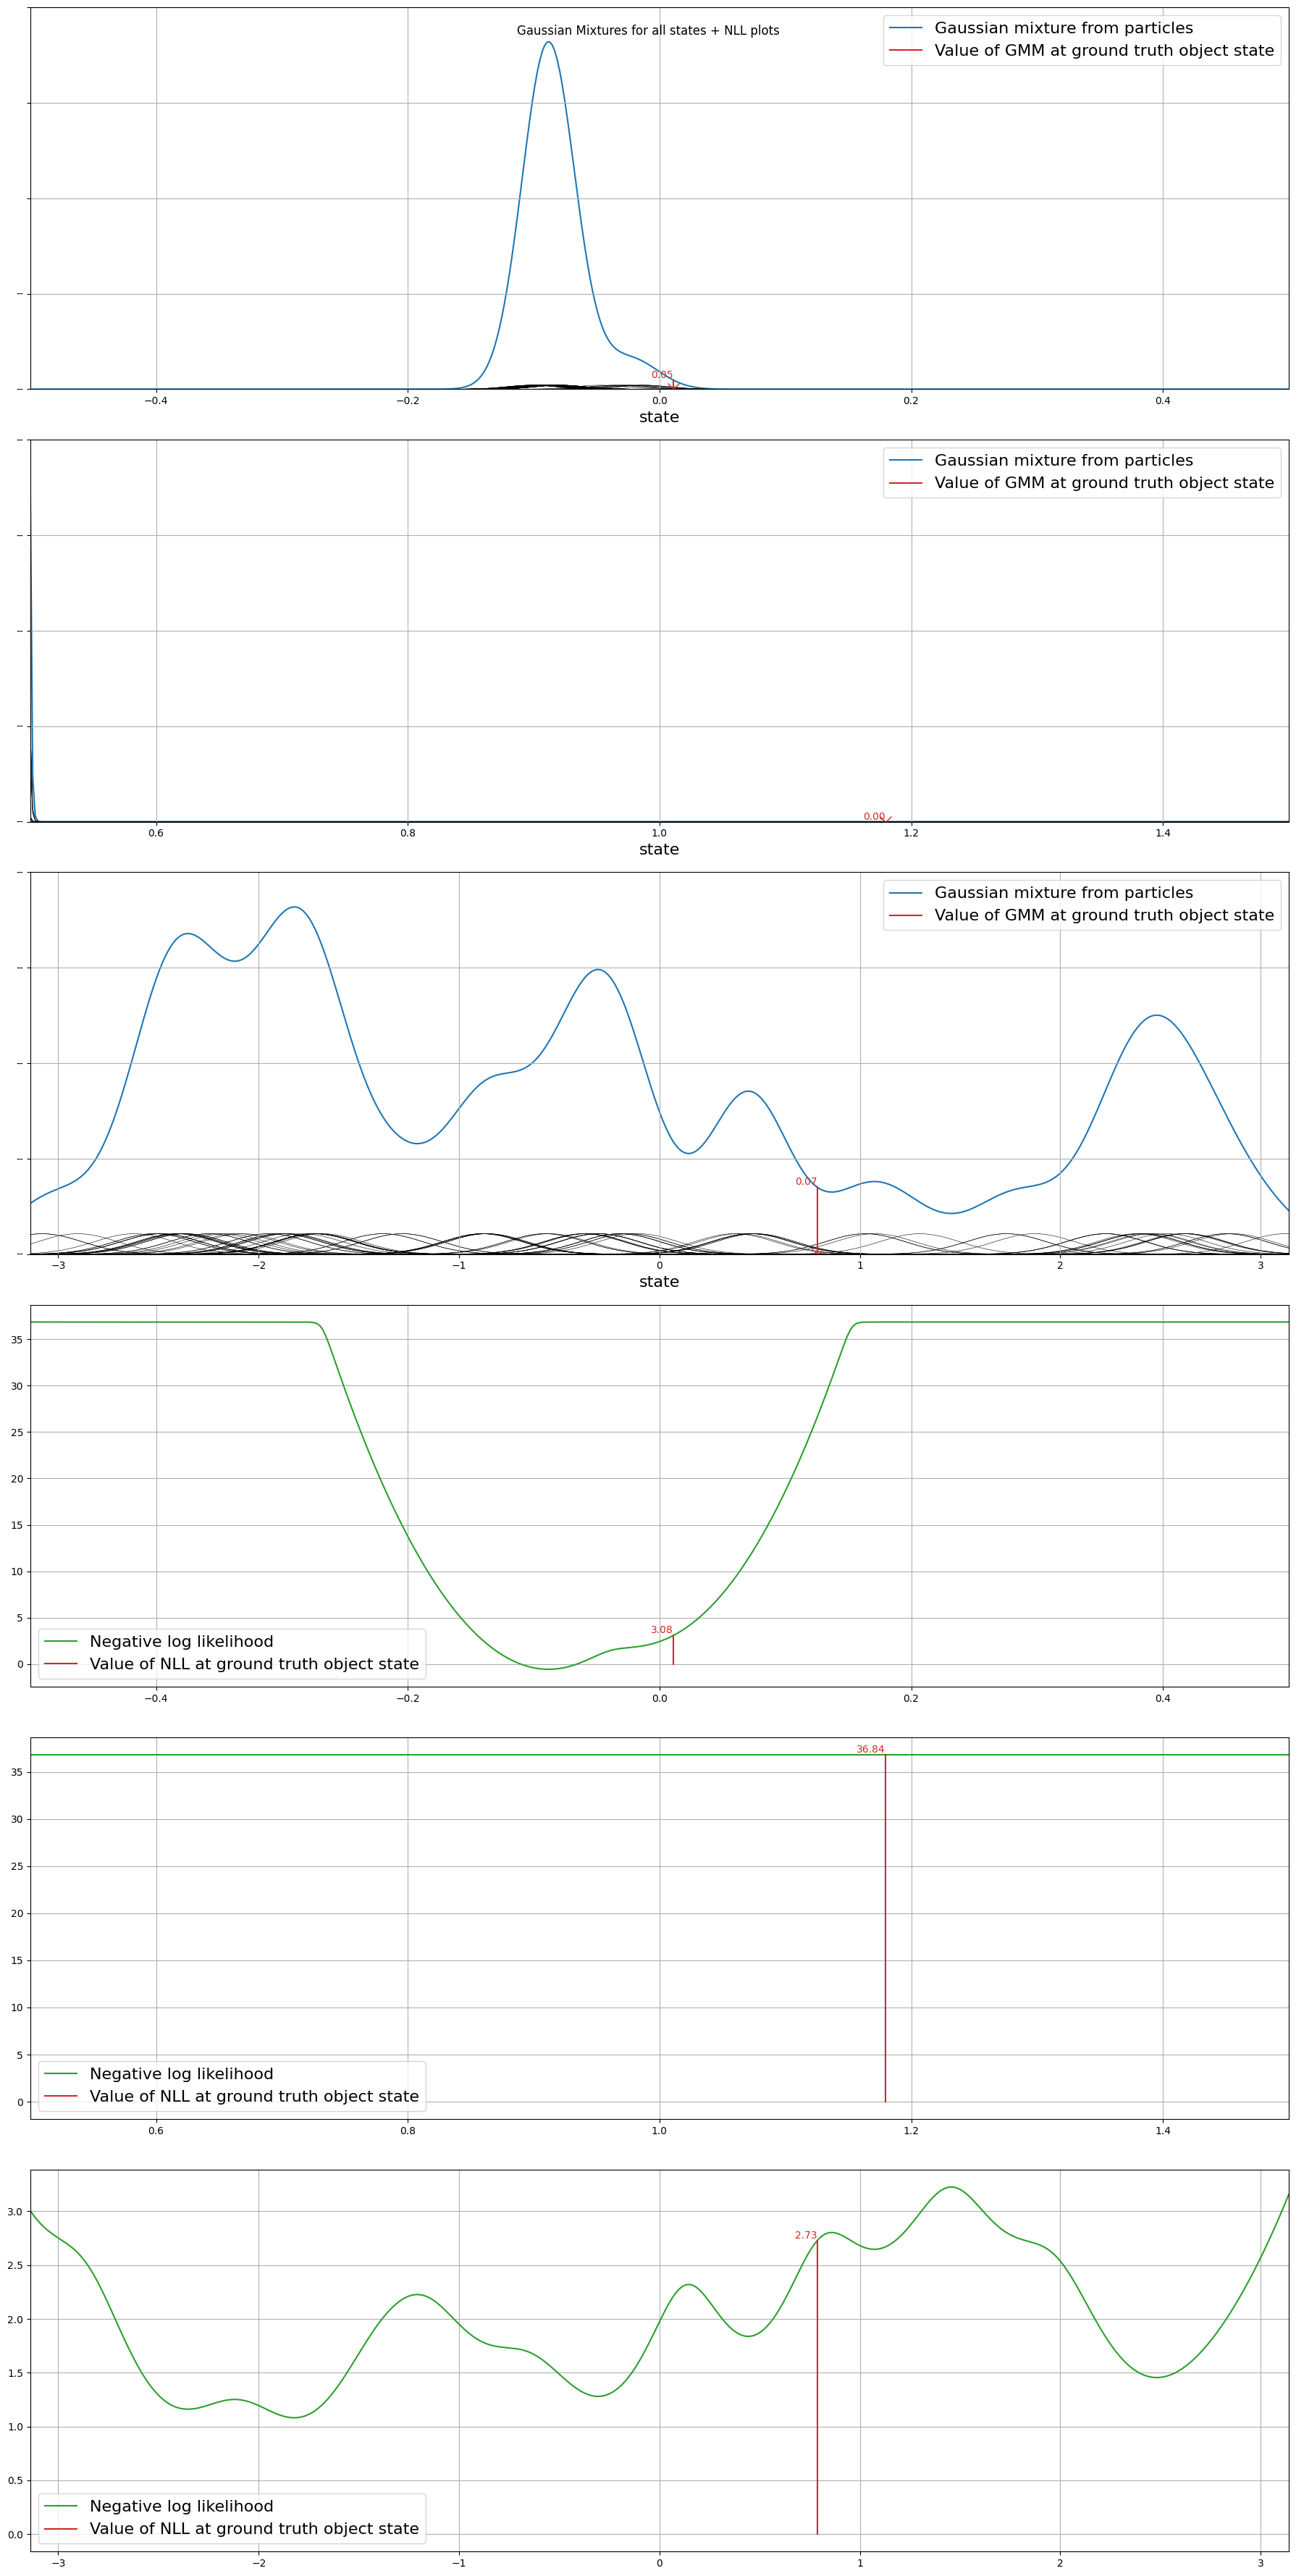

In [11]:
# # plot GMM
dpf.plot_GMM(q_o, particle_list, particle_prob_list, xy_only)

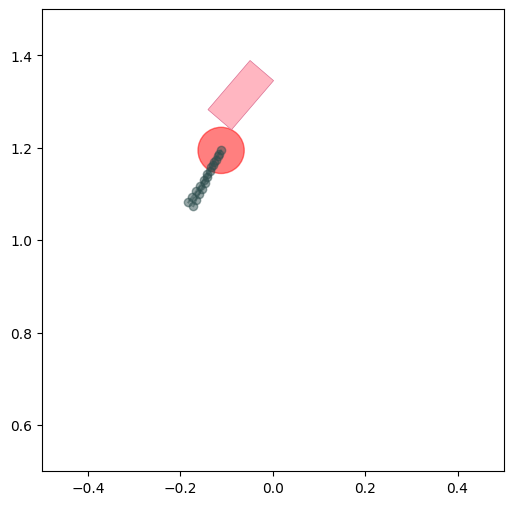

Desired robot position during contact event: tensor([[-0.1096,  1.1988]], dtype=torch.float64)
Achieved robot position during contact event: tensor([[-0.1117,  1.1946]], dtype=torch.float64)
Phi during contact event: tensor([[0.4890]], dtype=torch.float64)


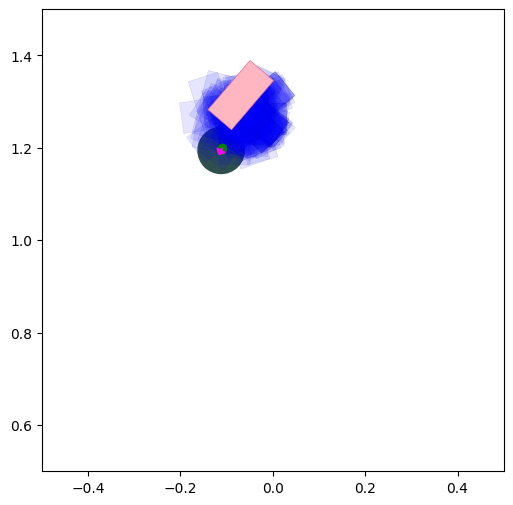

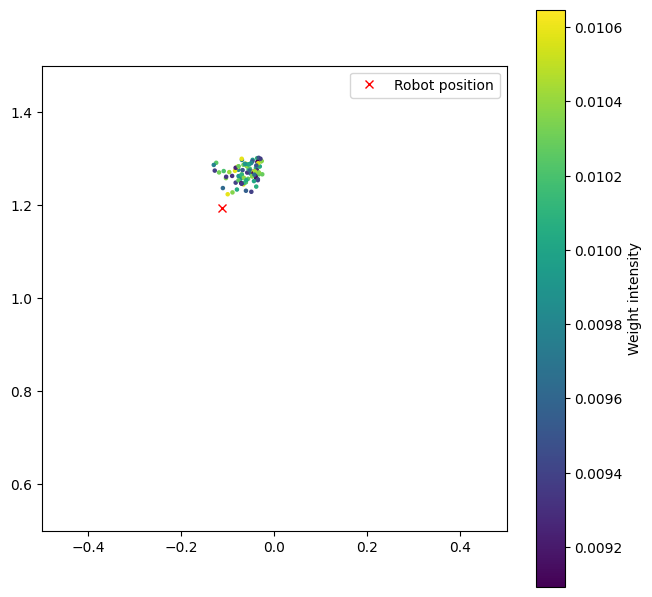

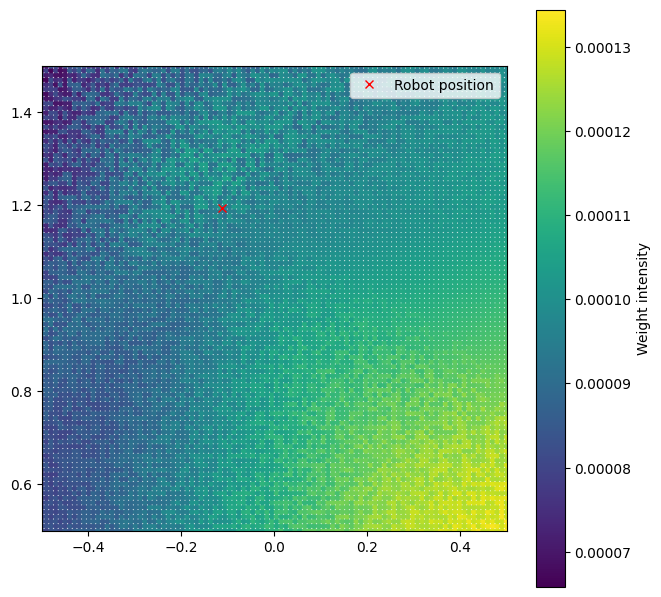

In [12]:
dpf.test(q_o_r_mins, q_o_r_maxs, means, stds, xy_only)